In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    recall_score, average_precision_score, classification_report,
    precision_recall_curve, ConfusionMatrixDisplay
)
import joblib

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("loans_full_schema.csv")
print(df.shape)
df['loan_status'].value_counts()

(10000, 56)


,count
loan_status,
Current,9375
Fully Paid,447
In Grace Period,67
Late (31-120 days),66
Late (16-30 days),38
Charged Off,7


In [3]:
# earliest_credit_line is a raw year (e.g. 2006) — turn it into a generalizable feature
df['issue_year'] = pd.to_datetime(df['issue_month'], format='%b-%Y').dt.year
df['credit_history_years'] = df['issue_year'] - df['earliest_credit_line']

# Target: 1 = any sign of payment distress observed so far, 0 otherwise. Full dataset.
risk_statuses = ['Late (16-30 days)', 'Late (31-120 days)', 'In Grace Period', 'Charged Off']
df['default_flag'] = df['loan_status'].isin(risk_statuses).astype(int)

print(df['default_flag'].value_counts())
print(f"Positive rate: {df['default_flag'].mean():.2%}")

default_flag
0    9822
1     178
Name: count, dtype: int64
Positive rate: 1.78%


In [4]:
# Leakage — excluded because they only exist once the loan is active and directly
# encode the outcome (balance/paid_total look very different for a charged-off loan):
# balance, paid_total, paid_principal, paid_interest, paid_late_fees

numeric_features = [
    'emp_length', 'annual_income', 'debt_to_income', 'delinq_2y',
    'months_since_last_delinq', 'credit_history_years', 'inquiries_last_12m',
    'total_credit_lines', 'open_credit_lines', 'total_credit_limit',
    'total_credit_utilized', 'num_collections_last_12m', 'num_historical_failed_to_pay',
    'months_since_90d_late', 'current_accounts_delinq', 'total_collection_amount_ever',
    'current_installment_accounts', 'accounts_opened_24m', 'months_since_last_credit_inquiry',
    'num_satisfactory_accounts', 'num_accounts_120d_past_due', 'num_accounts_30d_past_due',
    'num_active_debit_accounts', 'total_debit_limit', 'num_total_cc_accounts',
    'num_open_cc_accounts', 'num_cc_carrying_balance', 'num_mort_accounts',
    'account_never_delinq_percent', 'tax_liens', 'public_record_bankrupt',
    'loan_amount', 'term', 'interest_rate', 'installment'
]

categorical_features = [
    'state', 'homeownership', 'verified_income', 'loan_purpose',
    'application_type', 'grade', 'initial_listing_status', 'disbursement_method'
]

X = df[numeric_features + categorical_features]
y = df['default_flag']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

(8000, 43) (2000, 43)


In [6]:
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

In [7]:
param_grid = {
    'classifier__n_estimators': [200, 400],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_leaf': [1, 5, 10]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    pipeline, param_grid, cv=cv,
    scoring='average_precision',  # optimizes directly for PR-AUC
    n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)
print("Best CV PR-AUC:", grid_search.best_score_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Best CV PR-AUC: 0.06668130268598386


In [8]:
best_model = grid_search.best_estimator_
y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred_default = best_model.predict(X_test)  # uses a 0.5 threshold

baseline = y_test.mean()
test_prauc = average_precision_score(y_test, y_proba)

print(f"No-skill baseline: {baseline:.4f}")
print(f"Test PR-AUC: {test_prauc:.4f}  ({test_prauc/baseline:.1f}x baseline)")
print(f"Recall @ 0.5 threshold: {recall_score(y_test, y_pred_default):.3f}")
print(classification_report(y_test, y_pred_default, zero_division=0))

No-skill baseline: 0.0180
Test PR-AUC: 0.0502  (2.8x baseline)
Recall @ 0.5 threshold: 0.000
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1964
           1       0.00      0.00      0.00        36

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000



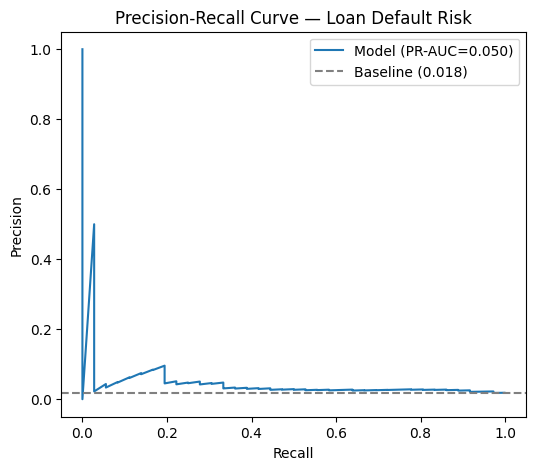

Threshold for ~50% recall: 0.0702 (precision at that point: 0.027)
              precision    recall  f1-score   support

           0       0.99      0.67      0.80      1964
           1       0.03      0.50      0.05        36

    accuracy                           0.67      2000
   macro avg       0.51      0.58      0.42      2000
weighted avg       0.97      0.67      0.78      2000



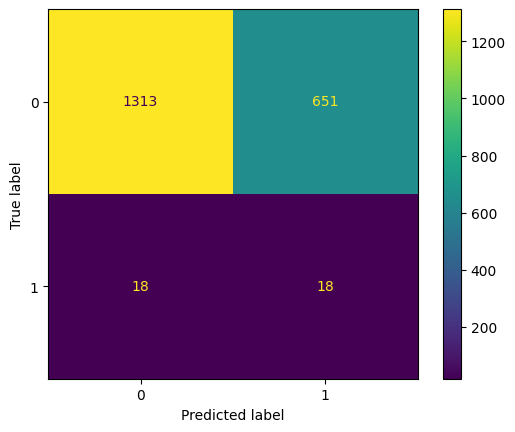

In [9]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'Model (PR-AUC={test_prauc:.3f})')
plt.axhline(baseline, color='gray', linestyle='--', label=f'Baseline ({baseline:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Loan Default Risk')
plt.legend()
plt.show()

# Pick a threshold that targets a chosen recall instead of the default 0.5
target_recall = 0.5
idx = np.argmin(np.abs(recall[:-1] - target_recall))
chosen_threshold = thresholds[idx]
print(f"Threshold for ~{target_recall:.0%} recall: {chosen_threshold:.4f} "
      f"(precision at that point: {precision[idx]:.3f})")

y_pred_tuned = (y_proba >= chosen_threshold).astype(int)
print(classification_report(y_test, y_pred_tuned, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned)
plt.show()

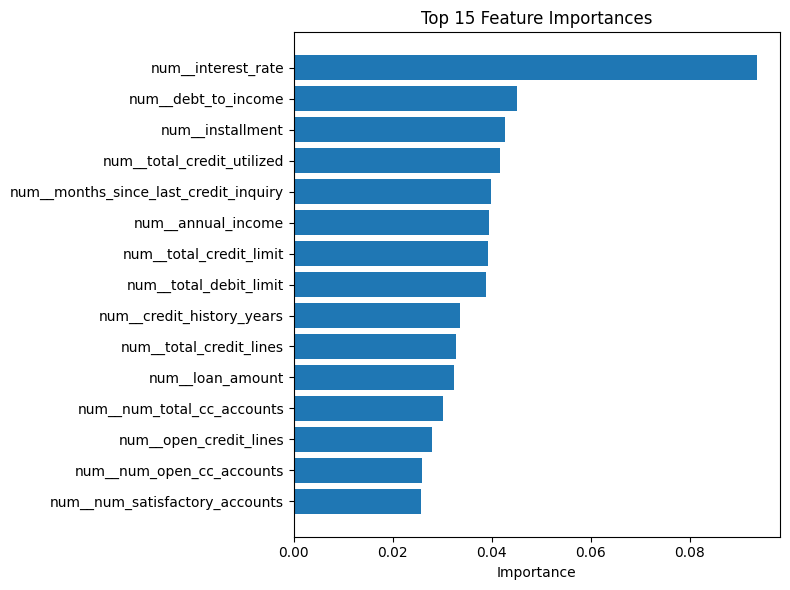

In [10]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}) \
    .sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'][::-1], importance_df['importance'][::-1])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [11]:
order = np.argsort(-y_proba)
top_decile_n = int(0.1 * len(y_proba))
captured = y_test.values[order[:top_decile_n]].sum()
total_positive = y_test.sum()
print(f"Flagging the riskiest 10% of test loans catches {captured}/{total_positive} "
      f"({captured/total_positive:.1%}) of all loans that showed payment risk.")

Flagging the riskiest 10% of test loans catches 10/36 (27.8%) of all loans that showed payment risk.


In [12]:
joblib.dump(best_model, "loan_default_pipeline.pkl")

from google.colab import files
files.download("loan_default_pipeline.pkl")  # optional, grabs a local copy

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>